In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


- HelpfulnessNumerator: The count of people who clicked [Yes].

- HelpfulnessDenominator: The total count of people who voted ([Yes] plus [No]).-

- Id	Row index / unique review ID	Ignore (not predictive).

- ProductId	Unique ID for the item being reviewed	Optional (helps group reviews by item).

- UserId	Unique ID for the reviewer	Optional (helps check if a reviewer is overly strict/generous).

- ProfileName	Display name of the reviewer	Ignore.

- Score	Target variable (1 to 5 stars)	This is what your model predicts.

- Time	Unix timestamp of when it was posted	Can show sentiment changes over time.

- SummaryShort review title/headlinePrimary text feature (can combine with Text).

- Text : Full body of the customer reviewPrimary text feature (convert to TF-IDF).

In [4]:
import pandas as pd

# 1. Load Dataset
df = pd.read_csv('Reviews.csv',on_bad_lines='skip',engine='python')

# 2. Drop Unnecessary Identifier Columns
columns_to_drop = ['Id', 'ProductId', 'UserId', 'ProfileName']
df = df.drop(columns=columns_to_drop)

# 3. Datetime Data Type Conversion
df['Time'] = pd.to_datetime(df['Time'], unit='s')

# 4. Handle Metadata Nulls & Duplicate Rows
df = df.dropna(subset=['Score'])  # Drop missing target scores
df = df.drop_duplicates(subset=['Text', 'Time'], keep='first') # This line scans your dataset for identical reviews posted at the exact same timestamp and removes the repeated copies, leaving only the original single entry.Dropping these duplicates prevents your TF-IDF model from learning over-represented spam words and avoids data leakage between your training and testing sets.

print("Phase 1 Complete - Non-Text Data Preprocessed.")
print(df[['HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time']].info())

Phase 1 Complete - Non-Text Data Preprocessed.
<class 'pandas.core.frame.DataFrame'>
Index: 99959 entries, 0 to 114472
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   HelpfulnessNumerator    99959 non-null  int64         
 1   HelpfulnessDenominator  99959 non-null  int64         
 2   Score                   99959 non-null  int64         
 3   Time                    99959 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 3.8 MB
None


In [5]:
import re   #The re library stands for Regular Expressions (RegEx). It is a built-in Python module used to search, match, and manipulate text based on specific pattern rules rather than exact word matches.

# 1. Handle Text Column Nulls
df['Summary'] = df['Summary'].fillna('')
df = df.dropna(subset=['Text'])



# 2. Combine Headline + Detailed Review Context
df['full_text'] = df['Summary'] + " " + df['Text']



# 3. Pure Regex String Cleaning Function
def clean_text_simple(text):
    # Remove HTML tags (e.g., <br />, <a>)
    text = re.sub(r'<.*?>', ' ', str(text))
    # Remove special characters, numbers, and punctuation (keep letters & spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase and strip extra trailing/leading whitespaces
    return text.lower().strip()

# 4. Apply Text Normalization
df['cleaned_text'] = df['full_text'].apply(clean_text_simple)



# 5. Review Length Statistics (Words per comment)
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

print("\nPhase 2 Complete - Text Normalized.")
print(df[['full_text', 'cleaned_text', 'word_count']].head(3))
print("\nWord Count Summary Statistics:")
print(df['word_count'].describe())


Phase 2 Complete - Text Normalized.
                                           full_text  \
0  Good Quality Dog Food I have bought several of...   
1  Not as Advertised Product arrived labeled as J...   
2  "Delight" says it all This is a confection tha...   

                                        cleaned_text  word_count  
0  good quality dog food i have bought several of...          52  
1  not as advertised product arrived labeled as j...          34  
2  delight says it all this is a confection that ...          96  

Word Count Summary Statistics:
count    99959.000000
mean        83.358677
std         75.755720
min          7.000000
25%         37.000000
50%         61.000000
75%        102.000000
max       2369.000000
Name: word_count, dtype: float64


In [6]:
# 2. Inspect word count distribution and quantiles
print("Word Count Summary Statistics:")
print(df['word_count'].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]))

# 3. Define Outlier Bounds
lower_limit = 2                                    # Filter out 0 or 1-word reviews (insufficient sentiment signal)
upper_limit = df['word_count'].quantile(0.99)      # 99th percentile (dynamically trims top 1% spam length)

print(f"\nLower Limit (Min words): {lower_limit}")
print(f"Upper Limit (99th percentile max words): {upper_limit:.0f}")

# 4. Filter Outliers
df_cleaned = df[(df['word_count'] >= lower_limit) & (df['word_count'] <= upper_limit)].copy()

print(f"\nOriginal Dataset Rows : {len(df)}")
print(f"Cleaned Dataset Rows  : {len(df_cleaned)}")
print(f"Outliers Removed      : {len(df) - len(df_cleaned)}")

Word Count Summary Statistics:
count    99959.000000
mean        83.358677
std         75.755720
min          7.000000
1%          19.000000
25%         37.000000
50%         61.000000
75%        102.000000
95%        219.000000
99%        374.000000
max       2369.000000
Name: word_count, dtype: float64

Lower Limit (Min words): 2
Upper Limit (99th percentile max words): 374

Original Dataset Rows : 99959
Cleaned Dataset Rows  : 98961
Outliers Removed      : 998


/tmp/ipykernel_2539/1854733475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='Score', palette='Blues_d')


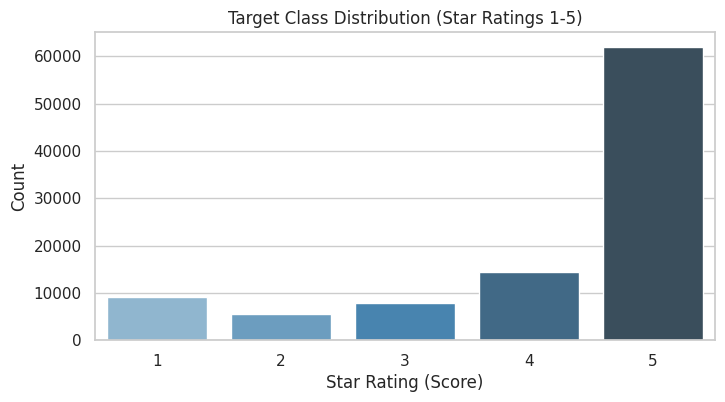

Percentage Breakdown of Star Ratings:
Score
5    62.61
4    14.66
1     9.25
3     7.97
2     5.51
Name: proportion, dtype: float64


/tmp/ipykernel_2539/1854733475.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Score', y='word_count', palette='Blues_d')


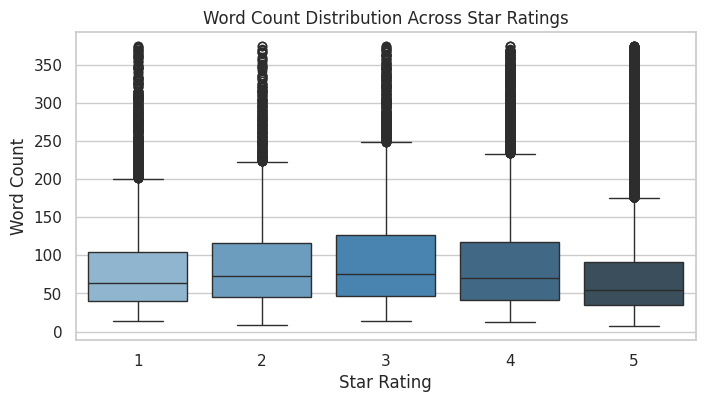


Average Word Count per Star Rating:
        mean  median    std
Score                      
1      82.02    64.0  59.83
2      90.16    73.0  62.47
3      95.76    76.0  67.58
4      90.39    70.0  66.61
5      72.77    55.0  55.67


/tmp/ipykernel_2539/1854733475.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=voted, x='Score', y='helpfulness_ratio', palette='Blues_d')


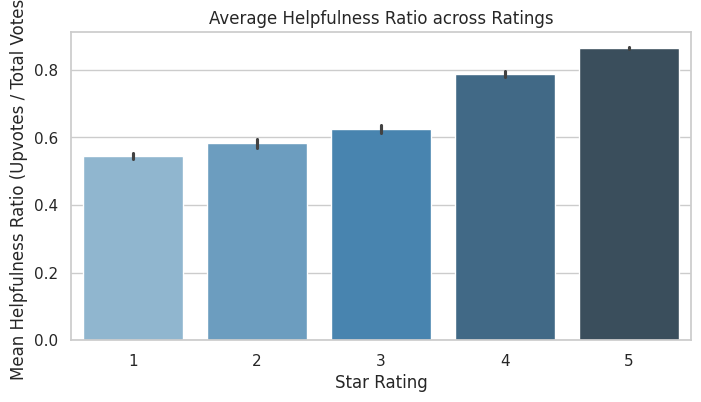

In [7]:
# Set visualization style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Target Class Imbalance (Score Distribution)
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.countplot(data=df_cleaned, x='Score', palette='Blues_d')
plt.title('Target Class Distribution (Star Ratings 1-5)')
plt.xlabel('Star Rating (Score)')
plt.ylabel('Count')
plt.show()

print("Percentage Breakdown of Star Ratings:")
print((df_cleaned['Score'].value_counts(normalize=True) * 100).round(2))

# ---------------------------------------------------------
# 2. Review Length (Word Count) vs. Star Rating
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_cleaned, x='Score', y='word_count', palette='Blues_d')
plt.title('Word Count Distribution Across Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Word Count')
plt.show()

print("\nAverage Word Count per Star Rating:")
print(df_cleaned.groupby('Score')['word_count'].agg(['mean', 'median', 'std']).round(2))

# ---------------------------------------------------------
# 3. Helpfulness Ratio vs. Star Rating
# ---------------------------------------------------------
# Calculate helpfulness ratio only for reviews that received votes
voted = df_cleaned[df_cleaned['HelpfulnessDenominator'] > 0].copy()
voted['helpfulness_ratio'] = voted['HelpfulnessNumerator'] / voted['HelpfulnessDenominator']

plt.figure(figsize=(8, 4))
sns.barplot(data=voted, x='Score', y='helpfulness_ratio', palette='Blues_d')
plt.title('Average Helpfulness Ratio across Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Mean Helpfulness Ratio (Upvotes / Total Votes)')
plt.show()

- graph 2:Long reviews naturally contain more words overall. If we just counted raw words, our model might get confused and think longer review = neutral score. Using L2 Normalization in TF-IDF fixes this by evaluating word importance as a proportion rather than relying on review length

- graph 3:A high helpfulness ratio strongly correlates with 4-star and 5-star ratings, proving that community upvotes align closely with positive sentiment.

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, cohen_kappa_score

# ---------------------------------------------------------
# 1. Train / Test Split
# ---------------------------------------------------------
X = df_cleaned['cleaned_text']
y = df_cleaned['Score'].values

# Stratify=y keeps star rating proportions identical in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 2. TF-IDF Feature Extraction
# ---------------------------------------------------------
# Convert clean text into a matrix of top 5,000 unigrams + bigrams
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)  # Captures single words ("bad") and 2-word phrases ("not bad")
)

# Fit on training data ONLY to prevent data leakage
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# ---------------------------------------------------------
# 3. Ordinal Model Training (Ridge Regression)
# ---------------------------------------------------------
# Treats ratings as a continuous scale (1.0 to 5.0) to preserve ordering
model = Ridge(alpha=1.0)
model.fit(X_train_vec, y_train)

# ---------------------------------------------------------
# 4. Post-Processing Predictions
# ---------------------------------------------------------
raw_preds = model.predict(X_test_vec)

# Clip output strictly within bounds [1, 5] and round to nearest integer star rating
clipped_preds = np.clip(raw_preds, 1, 5)
final_preds = np.round(clipped_preds).astype(int)

# ---------------------------------------------------------
# 5. Ordinal Metric Evaluation
# ---------------------------------------------------------
mae = mean_absolute_error(y_test, final_preds)
qwk = cohen_kappa_score(y_test, final_preds, weights='quadratic')

print("--- Ordinal Model Evaluation ---")
print(f"Mean Absolute Error (MAE)        : {mae:.4f}")
print(f"Quadratic Weighted Kappa (QWK)   : {qwk:.4f}")

--- Ordinal Model Evaluation ---
Mean Absolute Error (MAE)        : 0.5733
Quadratic Weighted Kappa (QWK)   : 0.7025


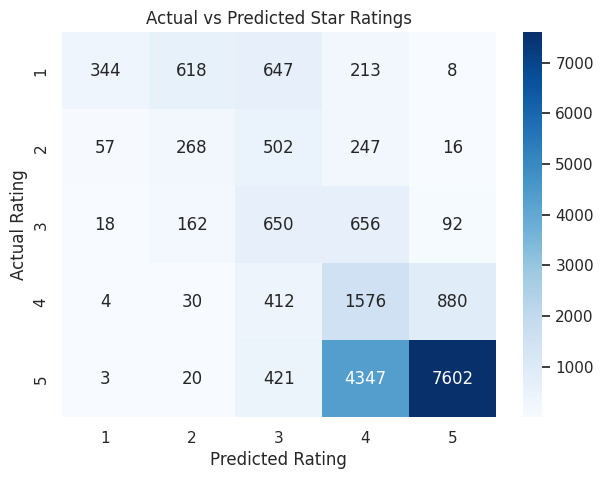

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])
plt.xlabel('Predicted Rating')
plt.ylabel('Actual Rating')
plt.title('Actual vs Predicted Star Ratings')
plt.show()